In [1]:
import os
import json
from pathlib import Path

def inspect_coco_datasets():
    base_path = Path("../data/raw")
    if not base_path.exists():
        base_path = Path("data/raw")
        
    print(f"🔍 Inspecting datasets in: {base_path.resolve()}\n")
    print("=" * 60)
    
    # Find all directories ending with .coco
    coco_dirs = [d for d in base_path.iterdir() if d.is_dir() and d.name.endswith('.coco')]
    
    if not coco_dirs:
        print("❌ No .coco directories found. Make sure you unzipped the files!")
        return
        
    for dataset_dir in sorted(coco_dirs):
        print(f"\n DATASET: {dataset_dir.name}")
        print("-" * 40)
        
        all_classes = set()
        
        # Look inside train, valid, test folders
        for split in ['train', 'valid', 'test']:
            split_path = dataset_dir / split
            if not split_path.exists():
                continue
                
            # Find the annotations JSON file
            json_files = list(split_path.glob('*_annotations.coco.json'))
            
            if json_files:
                json_file = json_files[0]
                with open(json_file, 'r') as f:
                    data = json.load(f)
                
                # Extract classes
                classes = [cat['name'] for cat in data.get('categories', [])]
                all_classes.update(classes)
                
                # Count images
                image_count = len(data.get('images', []))
                print(f"  ├─ {split.capitalize()}: {image_count} images")
            else:
                print(f"  ├─ {split.capitalize()}: No annotations found")
                
        print(f"  └─ Classes found: {sorted(list(all_classes))}")
        print("=" * 60)

# Run the function
inspect_coco_datasets()

🔍 Inspecting datasets in: /Users/macbook/Documents/ITC8/Internship/AI Farm/Project/car_defect_detection/data/raw


 DATASET: Car defect detection.v2i.coco
----------------------------------------
  ├─ Train: 2306 images
  ├─ Valid: 221 images
  ├─ Test: 110 images
  └─ Classes found: ['Accident', 'Dent', 'Glass-Break', 'Scratch', 'car-defect']

 DATASET: Car defect detection.v6i.coco
----------------------------------------
  ├─ Train: 2461 images
  ├─ Valid: 192 images
  ├─ Test: 49 images
  └─ Classes found: ['Accident', 'Dent', 'Glass-Break', 'Scratch', 'car-defect']

 DATASET: Rust Detection.v1i.coco
----------------------------------------
  ├─ Train: 9472 images
  ├─ Valid: 295 images
  ├─ Test: 296 images
  └─ Classes found: ['Rust', 'car', 'copper corrosion', 'corroded-part', 'corrosion', 'iron rust', 'mild-corrosion', 'moderate-corrosion', 'rust', 'severe-corrosion']

 DATASET: YoloForCarDefect.v1i.coco
----------------------------------------
  ├─ Train: 2508 images
  ├─ Vali

In [2]:
import os
import json
from pathlib import Path
from collections import Counter

def inspect_coco_datasets():
    base_path = Path("../data/raw")
    if not base_path.exists():
        base_path = Path("data/raw")
        
    print(f"🔍 Inspecting datasets in: {base_path.resolve()}\n")
    print("=" * 60)
    
    # Find all directories ending with .coco
    coco_dirs = [d for d in base_path.iterdir() if d.is_dir() and d.name.endswith('.coco')]
    
    if not coco_dirs:
        print("❌ No .coco directories found. Make sure you unzipped the files!")
        return
        
    for dataset_dir in sorted(coco_dirs):
        print(f"\n DATASET: {dataset_dir.name}")
        print("-" * 40)
        
        # Track object counts across all splits (train, valid, test)
        dataset_class_counts = Counter()
        
        # Look inside train, valid, test folders
        for split in ['train', 'valid', 'test']:
            split_path = dataset_dir / split
            if not split_path.exists():
                continue
                
            # Find the annotations JSON file
            json_files = list(split_path.glob('*_annotations.coco.json'))
            
            if json_files:
                json_file = json_files[0]
                with open(json_file, 'r') as f:
                    data = json.load(f)
                
                # Map category IDs to their names for this split
                id_to_name = {cat['id']: cat['name'] for cat in data.get('categories', [])}
                
                # Count the objects in this split's annotations
                annotations = data.get('annotations', [])
                for ann in annotations:
                    cat_id = ann.get('category_id')
                    cat_name = id_to_name.get(cat_id, "Unknown Class")
                    dataset_class_counts[cat_name] += 1
                
                # Count images
                image_count = len(data.get('images', []))
                print(f"  ├─ {split.capitalize()}: {image_count} images ({len(annotations)} total objects)")
            else:
                print(f"  ├─ {split.capitalize()}: No annotations found")
                
        # Print the breakdown of objects per class
        print("  └─ Class distribution (Total across all splits):")
        if dataset_class_counts:
            for class_name, count in sorted(dataset_class_counts.items()):
                print(f"     • {class_name}: {count} objects")
        else:
            print("     • No objects found.")
            
        print("=" * 60)

# Run the function
inspect_coco_datasets()

🔍 Inspecting datasets in: /Users/macbook/Documents/ITC8/Internship/AI Farm/Project/car_defect_detection/data/raw


 DATASET: Car defect detection.v2i.coco
----------------------------------------
  ├─ Train: 2306 images (3076 total objects)
  ├─ Valid: 221 images (296 total objects)
  ├─ Test: 110 images (146 total objects)
  └─ Class distribution (Total across all splits):
     • Accident: 325 objects
     • Dent: 1383 objects
     • Glass-Break: 312 objects
     • Scratch: 1498 objects

 DATASET: Car defect detection.v6i.coco
----------------------------------------
  ├─ Train: 2461 images (3476 total objects)
  ├─ Valid: 192 images (263 total objects)
  ├─ Test: 49 images (84 total objects)
  └─ Class distribution (Total across all splits):
     • Accident: 294 objects
     • Dent: 1737 objects
     • Glass-Break: 319 objects
     • Scratch: 1473 objects

 DATASET: Rust Detection.v1i.coco
----------------------------------------
  ├─ Train: 9472 images (52024 total objects)
  ├─ Val

In [4]:
import json


def get_coco_classes(json_path):
    """Extracts classes from a COCO format annotation file."""
    with open(json_path, "r") as f:
        data = json.load(f)

    # COCO formats use the 'categories' key
    categories = data.get("categories", [])
    classes = [cat["name"] for cat in categories]
    return classes


def get_supervisely_classes(json_path):
    """Extracts classes from a Supervisely metadata file."""
    with open(json_path, "r") as f:
        data = json.load(f)

    # This format uses the 'classes' key
    classes_list = data.get("classes", [])
    classes = [cls["title"] for cls in classes_list]
    return classes


# --- Execution ---

# Replace these with the actual paths to your files
coco_file_path = "/Users/macbook/Documents/ITC8/Internship/AI Farm/Project/car_defect_detection/data/raw/CarDD_release/CarDD_COCO/annotations/instances_train2017.json"
supervisely_file_path = "/Users/macbook/Documents/ITC8/Internship/AI Farm/Project/car_defect_detection/data/raw/archive/Car parts dataset/meta.json"

try:
    coco_classes = get_coco_classes(coco_file_path)
    print(f"Dataset 1 (COCO) Classes ({len(coco_classes)}):")
    print(coco_classes)
except FileNotFoundError:
    print(f"Could not find file at {coco_file_path}")

print("\n" + "=" * 40 + "\n")

try:
    supervisely_classes = get_supervisely_classes(supervisely_file_path)
    print(f"Dataset 2 (Supervisely) Classes ({len(supervisely_classes)}):")
    print(supervisely_classes)
except FileNotFoundError:
    print(f"Could not find file at {supervisely_file_path}")

Dataset 1 (COCO) Classes (6):
['dent', 'scratch', 'crack', 'glass shatter', 'lamp broken', 'tire flat']


Dataset 2 (Supervisely) Classes (8):
['Missing part', 'Broken part', 'Scratch', 'Cracked', 'Dent', 'Flaking', 'Paint chip', 'Corrosion']


In [150]:
import os
import json
import shutil
import random
from tqdm import tqdm
from collections import defaultdict

# ==========================================
# CONFIGURATION
# ==========================================
RAW_DATA_DIR = "/Users/macbook/Documents/ITC8/Internship/AI Farm/Project/car_defect_detection/data/raw"
OUTPUT_DIR = "/Users/macbook/Documents/ITC8/Internship/AI Farm/Project/car_defect_detection/data/processed"

TARGET_CLASSES = ["scratch", "dent", "stain", "rust", "broken"]
CLASS_TO_IDX = {cls: idx for idx, cls in enumerate(TARGET_CLASSES)}

# Dataset-Specific Rule Mapping Matrix
DATASET_MAPS = {
    "Car defect detection.v2i.coco": {
        "Scratch": "scratch", "Dent": "dent", "Glass-Break": "broken", "Accident": "broken", "car-defect": "broken"
    },
    "Car defect detection.v6i.coco": {
        "Scratch": "scratch", "Dent": "dent", "Glass-Break": "broken", "Accident": "broken", "car-defect": "broken"
    },
    "Rust Detection.v1i.coco": {
        "Rust": "rust", "rust": "rust", "copper corrosion": "rust", "corroded-part": "rust", 
        "corrosion": "rust", "iron rust": "rust", "mild-corrosion": "rust", "moderate-corrosion": "rust", 
        "severe-corrosion": "rust"
    },
    "crackbird detection 3.v6-v1.coco": {
        "Bird Drop": "stain", "Cracked": "broken"
    },
    "dd.v1i.coco": {
        "dent": "dent"
    },
    "scarcth_2.v9i.coco": {
        "scratch": "scratch", "scarcth-2": "scratch", "dent": "dent"
    },
    "socarC.v1i.coco": {
        "Scratched": "scratch", "Crushed": "dent", "Breakage": "broken", "Separated": "broken"
    },
    "YoloForCarDefect.v1i.coco": {
        "-": "dent", 
        "Roboflow is an end-to-end computer vision platform that helps you": "scratch", 
        "Car defect detection - v7 2024-04-12 10-29pm": "dent"
    }
}

MAX_IMAGES_PER_CLASS_TRAIN = 2000

# Clear out older processed attempts
if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)
for split in ['train', 'val', 'test']:
    os.makedirs(os.path.join(OUTPUT_DIR, split, 'images'), exist_ok=True)
    os.makedirs(os.path.join(OUTPUT_DIR, split, 'labels'), exist_ok=True)

# ==========================================
# METADATA PROCESSING ENGINE
# ==========================================
def run_strict_consolidation():
    # Pools split_pools[yolo_split][target_class] = []
    split_pools = {
        'train': defaultdict(list),
        'val': defaultdict(list),
        'test': defaultdict(list)
    }

    print("🔍 Scanning raw folders and translating rules...")
    
    for dataset_name in os.listdir(RAW_DATA_DIR):
        dataset_path = os.path.join(RAW_DATA_DIR, dataset_name)
        if not os.path.isdir(dataset_path):
            continue
            
        # Verify if explicit rules are configured for this directory
        if dataset_name not in DATASET_MAPS:
            print(f"⚠️ Skipping directory (No explicit rules defined): {dataset_name}")
            continue
            
        current_label_map = DATASET_MAPS[dataset_name]
        
        for split in ['train', 'valid', 'test']:
            split_dir = os.path.join(dataset_path, split)
            if not os.path.exists(split_dir) and split == 'valid':
                split_dir = os.path.join(dataset_path, 'val')
            if not os.path.exists(split_dir):
                continue
                
            json_file = os.path.join(split_dir, '_annotations.coco.json')
            if not os.path.exists(json_file):
                continue
                
            with open(json_file, 'r') as f:
                coco_data = json.load(f)
                
            categories = {cat['id']: cat['name'] for cat in coco_data['categories']}
            images = {img['id']: img for img in coco_data['images']}
            
            img_to_anns = defaultdict(list)
            for ann in coco_data['annotations']:
                img_to_anns[ann['image_id']].append(ann)
                
            yolo_split = 'val' if split in ['valid', 'val'] else split
            
            for img_id, anns in img_to_anns.items():
                img_info = images[img_id]
                src_img_path = os.path.join(split_dir, img_info['file_name'])
                if not os.path.exists(src_img_path):
                    continue
                    
                yolo_lines = []
                detected_classes_in_image = set()
                
                for ann in anns:
                    raw_label = categories.get(ann['category_id'])
                    target_class = current_label_map.get(raw_label)
                    
                    # Skip if the raw label is unmapped or explicitly omitted
                    if not target_class:
                        continue
                        
                    # Verify polygon segmentation info exists
                    if 'segmentation' not in ann or not ann['segmentation']:
                        continue
                        
                    class_idx = CLASS_TO_IDX[target_class]
                    img_w, img_h = img_info['width'], img_info['height']
                    
                    for seg in ann['segmentation']:
                        if len(seg) < 6: 
                            continue
                        normalized_coords = []
                        for i in range(0, len(seg), 2):
                            nx = max(0.0, min(1.0, seg[i] / img_w))
                            ny = max(0.0, min(1.0, seg[i+1] / img_h))
                            normalized_coords.append(f"{nx:.6f}")
                            normalized_coords.append(f"{ny:.6f}")
                        
                        yolo_lines.append(f"{class_idx} " + " ".join(normalized_coords))
                        detected_classes_in_image.add(target_class)
                
                # If valid instances were parsed, store them into the pipeline pool
                if yolo_lines:
                    primary_class = sorted(list(detected_classes_in_image))[0]
                    split_pools[yolo_split][primary_class].append({
                        'src_path': src_img_path,
                        'lines': yolo_lines,
                        'ext': os.path.splitext(img_info['file_name'])[1]
                    })

    # ==========================================
    # BALANCING AND WRITING PIPELINE
    # ==========================================
    print("\n⚖️ Enforcing image-level balancing & compiling files...")
    global_file_counter = 0
    final_mask_stats = defaultdict(int)

    for yolo_split, classes_dict in split_pools.items():
        print(f" Processing Split: [{yolo_split}]")
        for target_class in TARGET_CLASSES:
            img_list = classes_dict[target_class]
            
            # Shuffle to remove dataset scanning ordering bias
            random.seed(42)
            random.shuffle(img_list)
            
            # Apply hard image limit caps on the training partition
            if yolo_split == 'train' and len(img_list) > MAX_IMAGES_PER_CLASS_TRAIN:
                img_list = img_list[:MAX_IMAGES_PER_CLASS_TRAIN]
                
            for item in img_list:
                global_file_counter += 1
                unique_img_name = f"car_defect_{global_file_counter:06d}{item['ext']}"
                unique_lbl_name = f"car_defect_{global_file_counter:06d}.txt"
                
                # Copy raw images to output structure
                shutil.copy(item['src_path'], os.path.join(OUTPUT_DIR, yolo_split, 'images', unique_img_name))
                
                # Save label data
                with open(os.path.join(OUTPUT_DIR, yolo_split, 'labels', unique_lbl_name), 'w') as lf:
                    lf.write("\n".join(item['lines']))
                
                # Update statistics
                for line in item['lines']:
                    c_idx = int(line.split()[0])
                    final_mask_stats[TARGET_CLASSES[c_idx]] += 1

    print("\n=============================================")
    print("📊 CUSTOM RULE CONSOLIDATION COMPLETE")
    for cls in TARGET_CLASSES:
        print(f" ├─ {cls}: {final_mask_stats[cls]} polygon masks written")
    print("=============================================")

if __name__ == "__main__":
    run_strict_consolidation()

🔍 Scanning raw folders and translating rules...

⚖️ Enforcing image-level balancing & compiling files...
 Processing Split: [train]
 Processing Split: [val]
 Processing Split: [test]

📊 CUSTOM RULE CONSOLIDATION COMPLETE
 ├─ scratch: 19606 polygon masks written
 ├─ dent: 5217 polygon masks written
 ├─ stain: 1848 polygon masks written
 ├─ rust: 6678 polygon masks written
 ├─ broken: 6354 polygon masks written


📦 Active Dataset: YoloForCarDefect.v1i.coco
🏷️ Available Classes: ['car-defects', '-', 'Car defect detection - v7 2024-04-12 10-29pm', 'Roboflow is an end-to-end computer vision platform that helps you']



/var/folders/ff/qg2c3gnd6cq9q6ytcr63h8br0000gn/T/ipykernel_98665/1920846653.py:79: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", len(unique_classes))


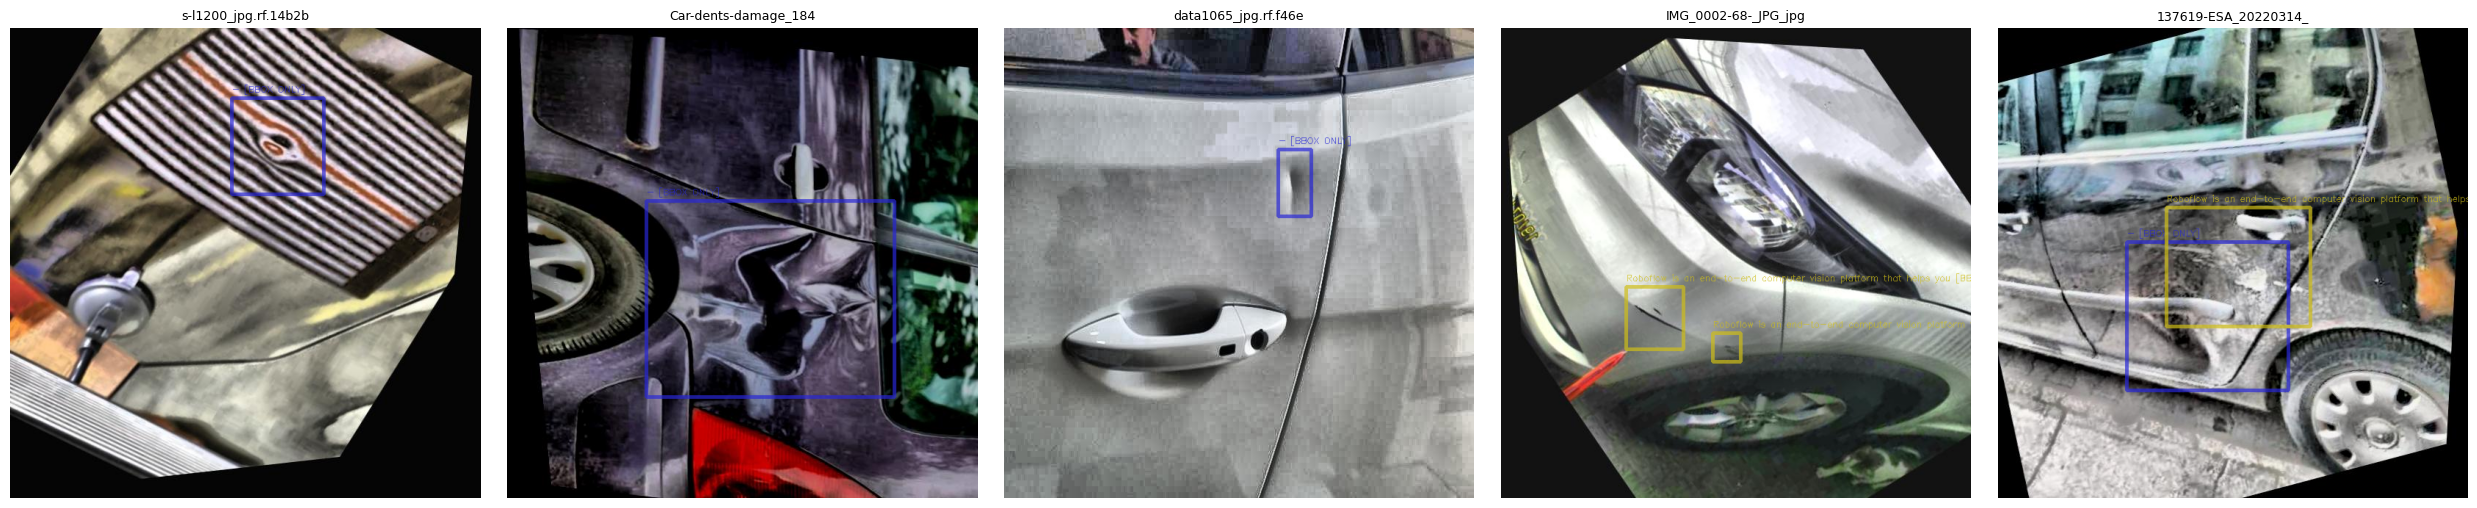

In [148]:
import os
import json
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 🔄 REPLACE THIS VARIABLE TO SWITCH DATASETS
# ==========================================
# Paste any folder name from your raw data directory here:
DATASET_NAME = "YoloForCarDefect.v1i.coco"
# Other options you have:
# "Rust Detection.v1i.coco"
# "car damage.v1i.coco"
# "crackbird detection 3.v6-v1.coco"
# "scarcth_2.v9i.coco"
# "socarC.v1i.coco"
# "YoloForCarDefect.v1i.coco"
# "car defect.v1i.coco"

RAW_DIR = "/Users/macbook/Documents/ITC8/Internship/AI Farm/Project/car_defect_detection/data/raw"
SPLIT_TO_CHECK = "train"  # Options: 'train', 'valid', 'test'

# ==========================================
# VISUALIZATION ENGINE
# ==========================================
def inspect_specific_dataset(num_images=5):
    dataset_path = os.path.join(RAW_DIR, DATASET_NAME)
    
    # Handle folder path validation
    if not os.path.exists(dataset_path):
        print(f"❌ Dataset folder not found: {dataset_path}")
        return
        
    split_dir = os.path.join(dataset_path, SPLIT_TO_CHECK)
    if not os.path.exists(split_dir) and SPLIT_TO_CHECK == "valid":
        split_dir = os.path.join(dataset_path, "val")
        
    json_path = os.path.join(split_dir, "_annotations.coco.json")
    
    if not os.path.exists(json_path):
        print(f"❌ Could not find _annotations.coco.json in split: {SPLIT_TO_CHECK}")
        return

    # Load annotations
    with open(json_path, 'r') as f:
        coco_data = json.load(f)
        
    categories = {cat['id']: cat['name'] for cat in coco_data['categories']}
    images_dict = {img['id']: img for img in coco_data['images']}
    
    print(f"📦 Active Dataset: {DATASET_NAME}")
    print(f"🏷️ Available Classes: {list(categories.values())}\n")
    
    # Map images to annotations
    img_to_anns = {}
    for ann in coco_data['annotations']:
        img_id = ann['image_id']
        if img_id not in img_to_anns:
            img_to_anns[img_id] = []
        img_to_anns[img_id].append(ann)
        
    annotated_image_ids = list(img_to_anns.keys())
    if not annotated_image_ids:
        print("⚠️ No annotations found in this split.")
        return
        
    num_images = min(num_images, len(annotated_image_ids))
    sampled_img_ids = random.sample(annotated_image_ids, num_images)
    
    # Plotting layout
    fig, axes = plt.subplots(1, num_images, figsize=(5 * num_images, 5))
    if num_images == 1:
        axes = [axes]
        
    # Color mapping
    unique_classes = list(categories.values())
    cmap = plt.cm.get_cmap("tab10", len(unique_classes))
    class_colors = {cls: [int(x*255) for x in cmap(i)[:3]] for i, cls in enumerate(unique_classes)}

    for idx, img_id in enumerate(sampled_img_ids):
        img_info = images_dict[img_id]
        img_file_path = os.path.join(split_dir, img_info['file_name'])
        ax = axes[idx]
        
        img = cv2.imread(img_file_path)
        if img is None:
            ax.text(0.5, 0.5, f"Missing:\n{img_info['file_name']}", ha='center', va='center')
            ax.axis('off')
            continue
            
        overlay = img.copy()
        anns = img_to_anns[img_id]
        
        for ann in anns:
            class_name = categories.get(ann['category_id'], "unknown")
            color = class_colors.get(class_name, (255, 255, 255))
            
            # Check if it has segmentation polygon shapes
            if 'segmentation' in ann and ann['segmentation']:
                for seg in ann['segmentation']:
                    if len(seg) >= 6:
                        pts = np.array(seg, dtype=np.int32).reshape((-1, 1, 2))
                        cv2.fillPoly(overlay, [pts], color)
                        cv2.polylines(img, [pts], isClosed=True, color=color, thickness=3)
                        # Text for polygon detection
                        text_pos = (pts[0][0][0], max(pts[0][0][1] - 10, 15))
                        cv2.putText(img, class_name, text_pos, cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
            else:
                # If polygon data is missing, draw bounding box fallback
                if 'bbox' in ann and len(ann['bbox']) == 4:
                    x, y, w_box, h_box = map(int, ann['bbox'])
                    cv2.rectangle(img, (x, y), (x + w_box, y + h_box), color, 3)
                    # Text showing the real class + BBOX warning
                    label_text = f"{class_name} [BBOX ONLY]"
                    cv2.putText(img, label_text, (x, max(y - 8, 15)), cv2.FONT_HERSHEY_SIMPLEX, 0.4, color, 1)

        # Transparency blend
        rendered_img = cv2.addWeighted(overlay, 0.3, img, 0.7, 0)
        rendered_img = cv2.cvtColor(rendered_img, cv2.COLOR_BGR2RGB)
        
        ax.imshow(rendered_img)
        ax.set_title(f"{img_info['file_name'][:20]}", fontsize=9)
        ax.axis('off')
        
    plt.tight_layout()
    plt.show()

# Execute cell
inspect_specific_dataset(num_images=5)

In [14]:
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# CONFIGURATION
# ==========================================
PROCESSED_DIR = "/Users/macbook/Documents/ITC8/Internship/AI Farm/Project/car_defect_detection/data/processed"
SPLIT = "train"  # Options: 'train', 'val', 'test'

TARGET_CLASSES = ["scratch", "dent", "stain", "rust", "broken"]

# Distinct color palette for our 5 target classes (BGR format)
CLASS_COLORS = {
    0: (0, 255, 255),   # Yellow for Scratch
    1: (255, 0, 255),   # Magenta for Dent
    2: (0, 255, 0),     # Green for Stain
    3: (0, 0, 255),     # Red for Rust
    4: (255, 128, 0)    # Cyan/Blue for Broken
}

images_dir = os.path.join(PROCESSED_DIR, SPLIT, "images")
labels_dir = os.path.join(PROCESSED_DIR, SPLIT, "labels")

# ==========================================
# VISUALIZATION ENGINE
# ==========================================
def verify_processed_dataset(num_images=3):
    all_images = [f for f in os.listdir(images_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    if len(all_images) < num_images:
        print(f"⚠️ Only found {len(all_images)} images in {images_dir}.")
        num_images = len(all_images)
        
    if num_images == 0:
        print("❌ No processed images found!")
        return

    # Sample exactly 3 images
    sampled_images = random.sample(all_images, num_images)
    
    # Setup matplotlib grid (1 row, 3 columns)
    fig, axes = plt.subplots(1, num_images, figsize=(6 * num_images, 6))
    if num_images == 1:
        axes = [axes]

    for idx, img_name in enumerate(sampled_images):
        ax = axes[idx]
        base_name = os.path.splitext(img_name)[0]
        lbl_name = f"{base_name}.txt"
        
        img_path = os.path.join(images_dir, img_name)
        lbl_path = os.path.join(labels_dir, lbl_name)
        
        # Load processed image
        image = cv2.imread(img_path)
        if image is None:
            ax.text(0.5, 0.5, f"Error Loading:\n{img_name}", ha='center', va='center')
            ax.axis('off')
            continue
            
        h, w, _ = image.shape
        overlay = image.copy()
        
        # Parse YOLO segmentation text file
        if os.path.exists(lbl_path):
            with open(lbl_path, 'r') as f:
                lines = f.readlines()
                
            for line in lines:
                parts = line.strip().split()
                if len(parts) < 7: 
                    continue
                    
                class_idx = int(parts[0])
                # Reconstruct normalized coordinates back into pixel coordinates
                coords = np.array([float(x) for x in parts[1:]], dtype=np.float32).reshape(-1, 2)
                coords[:, 0] *= w
                coords[:, 1] *= h
                pts = coords.astype(np.int32).reshape((-1, 1, 2))
                
                color = CLASS_COLORS.get(class_idx, (255, 255, 255))
                class_name = TARGET_CLASSES[class_idx]
                
                # Draw the filled polygon mask layer
                cv2.fillPoly(overlay, [pts], color)
                # Draw crisp outline border
                cv2.polylines(image, [pts], isClosed=True, color=color, thickness=2)
                
                # Place class text near the first coordinate point
                text_pos = (int(coords[0][0]), max(int(coords[0][1]) - 8, 15))
                cv2.putText(image, class_name, text_pos, cv2.FONT_HERSHEY_SIMPLEX, 
                            0.5, color, 2, cv2.LINE_AA)
        
        # Blend the original image with the colored mask layer (75% original, 25% mask color)
        final_output = cv2.addWeighted(overlay, 0.25, image, 0.75, 0)
        final_output = cv2.cvtColor(final_output, cv2.COLOR_BGR2RGB)
        
        # Render on the matplotlib grid layout
        ax.imshow(final_output)
        ax.set_title(f"{img_name}\n({w}x{h})", fontsize=11)
        ax.axis('off')
        
    plt.tight_layout()
    plt.show()

# Run validation grid
verify_processed_dataset(num_images=3)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/macbook/Documents/ITC8/Internship/AI Farm/Project/car_defect_detection/data/processed/train/images'

In [15]:
import os
import json
from collections import Counter
from pathlib import Path

def check_dataset_classes(absolute_dataset_path):
    base_dir = Path(absolute_dataset_path)
    class_counter = Counter()
    total_images = 0
    
    # FIX: Use a relative pattern inside glob()
    json_files = list(base_dir.glob("**/ann/*.json"))
    
    if not json_files:
        print(f"No annotation files found in: {absolute_dataset_path}\nPlease verify the path exists.")
        return

    for json_path in json_files:
        total_images += 1
        with open(json_path, "r", encoding="utf-8") as f:
            try:
                data = json.load(f)
                for obj in data.get("objects", []):
                    class_title = obj.get("classTitle")
                    if class_title:
                        class_counter[class_title] += 1
            except Exception as e:
                print(f"Error reading {json_path}: {e}")
                
    print(f"=== Dataset Analysis Report ===")
    print(f"Total annotated images found: {total_images}")
    print(f"Unique classes found ({len(class_counter)} total):")
    for class_name, count in class_counter.most_common():
        print(f"  - {class_name}: {count} annotations")

# Define absolute paths to your data folders safely
data_root = "/Users/macbook/Documents/ITC8/Internship/AI Farm/Project/car_defect_detection/data/raw/archive"

print("Analyzing Car Parts Dataset...")
check_dataset_classes(f"{data_root}/Car parts dataset")

print("\nAnalyzing Car Damages Dataset...")
check_dataset_classes(f"{data_root}/Car damages dataset")

Analyzing Car Parts Dataset...
=== Dataset Analysis Report ===
Total annotated images found: 814
Unique classes found (8 total):
  - Scratch: 3242 annotations
  - Dent: 1664 annotations
  - Broken part: 1500 annotations
  - Paint chip: 1356 annotations
  - Missing part: 632 annotations
  - Flaking: 337 annotations
  - Corrosion: 277 annotations
  - Cracked: 76 annotations

Analyzing Car Damages Dataset...
=== Dataset Analysis Report ===
Total annotated images found: 998
Unique classes found (21 total):
  - Back-window: 1237 annotations
  - Mirror: 987 annotations
  - Front-window: 951 annotations
  - Fender: 935 annotations
  - Front-door: 917 annotations
  - Headlight: 914 annotations
  - Front-wheel: 885 annotations
  - Back-wheel: 865 annotations
  - Rocker-panel: 860 annotations
  - Quarter-panel: 855 annotations
  - Roof: 793 annotations
  - Tail-light: 721 annotations
  - Back-door: 721 annotations
  - Hood: 712 annotations
  - Front-bumper: 705 annotations
  - Windshield: 632 an

Visualizing Car Parts Dataset:


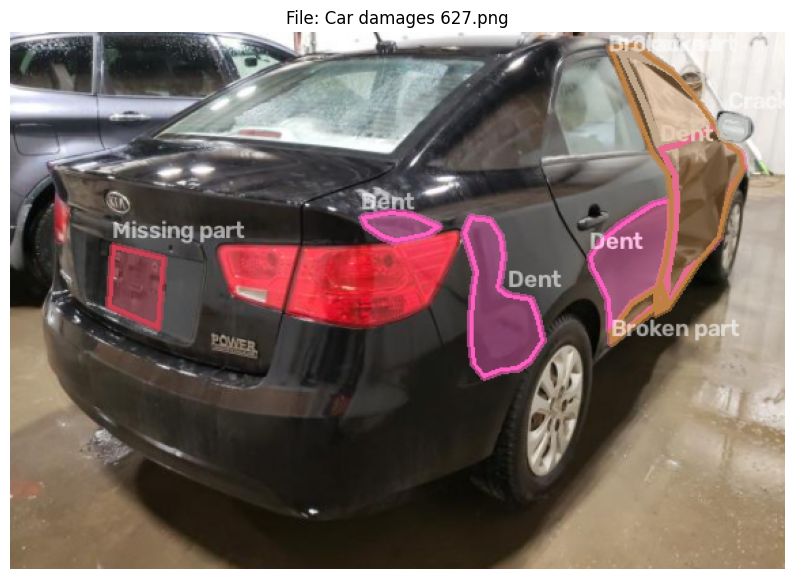

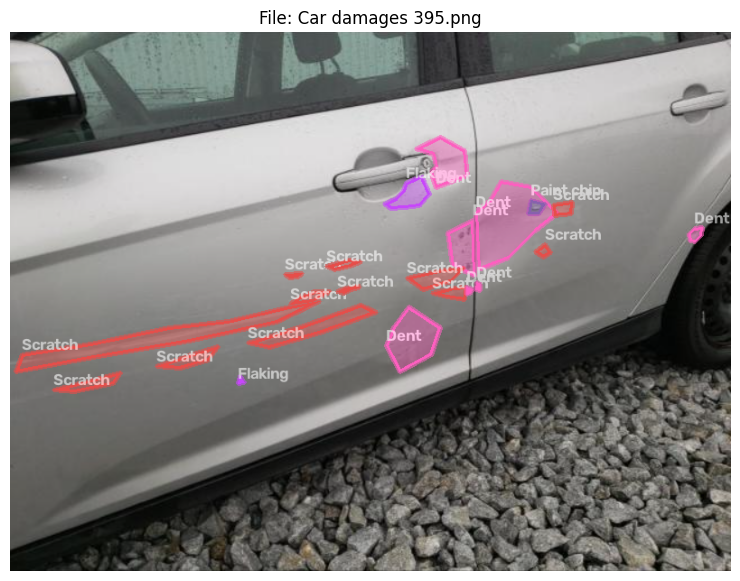

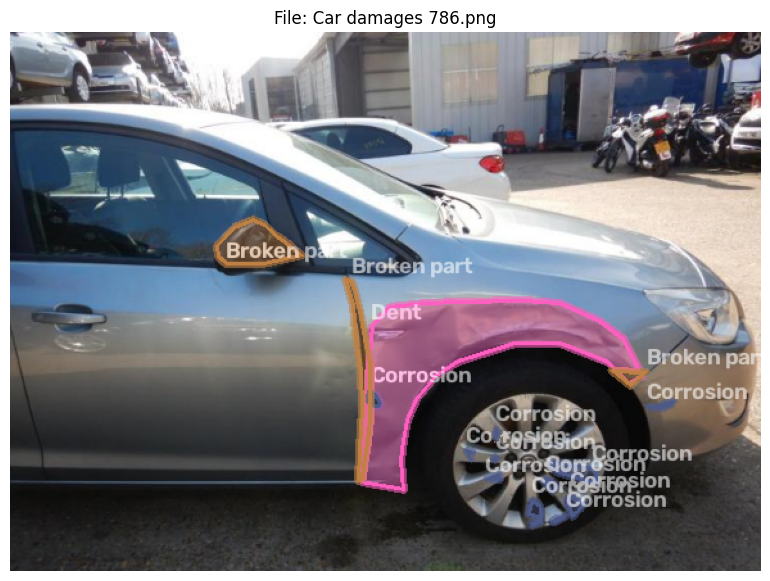

In [21]:
import os
import json
import random
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

def visualize_random_samples(absolute_dataset_path, num_samples=3):
    base_dir = Path(absolute_dataset_path)
    
    # FIX: Use a relative pattern inside glob()
    json_files = list(base_dir.glob("**/ann/*.json"))
    
    if len(json_files) < num_samples:
        print(f"Not enough annotations found to select {num_samples} samples.")
        return
        
    selected_jsons = random.sample(json_files, num_samples)
    class_colors = {}
    
    for json_path in selected_jsons:
        with open(json_path, "r", encoding="utf-8") as f:
            ann_data = json.load(f)
            
        img_name_stem = json_path.name.replace(".json", "")
        img_dir = json_path.parent.parent / "img"
        img_path = img_dir / img_name_stem
        
        if not img_path.exists():
            img_path = next(img_dir.glob(f"{Path(img_name_stem).stem}.*"), None)
            
        if not img_path or not img_path.exists():
            print(f"Could not find matching image for: {json_path.name}")
            continue
            
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        overlay = img.copy()
        
        for obj in ann_data.get("objects", []):
            class_title = obj.get("classTitle", "Unknown")
            points = obj.get("points", {}).get("exterior", [])
            
            if not points:
                continue
                
            if class_title not in class_colors:
                class_colors[class_title] = [random.randint(50, 255) for _ in range(3)]
            color = class_colors[class_title]
            
            pts = np.array(points, dtype=np.int32)
            cv2.fillPoly(overlay, [pts], color=color)
            cv2.polylines(img, [pts], isClosed=True, color=color, thickness=3)
            
            text_pos = tuple(pts[0])
            cv2.putText(img, class_title, (text_pos[0], max(text_pos[1]-5, 15)), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2, cv2.LINE_AA)
        
        final_img = cv2.addWeighted(overlay, 0.4, img, 0.6, 0)
        
        plt.figure(figsize=(10, 7))
        plt.imshow(final_img)
        plt.title(f"File: {img_path.name}")
        plt.axis('off')
        plt.show()

# Run visualization using the fixed absolute path structure
data_root = "/Users/macbook/Documents/ITC8/Internship/AI Farm/Project/car_defect_detection/data/raw/archive"

print("Visualizing Car Parts Dataset:")
visualize_random_samples(f"{data_root}/Car parts dataset", num_samples=3)